# Enviando Imagens para a API do Gemini com Output Estruturado

Este notebook demonstra como carregar uma imagem da pasta local `imagens` e usar o SDK oficial do Google (`google-genai`) para enviá-la e forçar o Gemini a responder de forma estruturada (Structured Output, em JSON), usando o `Pydantic` para definir o formato esperado.

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

if os.environ.get("GEMINI_API_KEY"):
    print("Chave de API (GEMINI_API_KEY) carregada com sucesso!")
else:
    print("Atenção: Você precisa adicionar 'GEMINI_API_KEY=sua_chave' no arquivo .env!")


Chave de API (GEMINI_API_KEY) carregada com sucesso!


Imagens encontradas:
[0] ../assets\caoegato.jpg
[1] ../assets\imagenet_classes.txt
[2] ../assets\passaro.jpg
[3] ../assets\pizza.jpg

Carregando a imagem: ../assets\caoegato.jpg


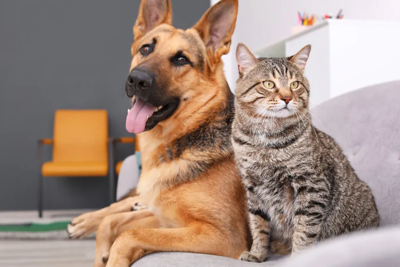

In [2]:
import glob
from PIL import Image
from IPython.display import display

lista_imagens = glob.glob("../assets/*")
print("Imagens encontradas:")
for i, img in enumerate(lista_imagens):
    print(f"[{i}] {img}")

if len(lista_imagens) > 0:
    caminho_imagem = lista_imagens[0]
    print(f"\nCarregando a imagem: {caminho_imagem}")
    imagem = Image.open(caminho_imagem)

    imagem_miniatura = imagem.copy()
    imagem_miniatura.thumbnail((400, 400))
    display(imagem_miniatura)
else:
    print("Nenhuma imagem encontrada na pasta 'imagens'.")


In [3]:
from google import genai
from google.genai import types
from pydantic import BaseModel
import json

# ===== Modelo =====
class AnaliseImagem(BaseModel):
    descricao_geral: str
    elementos_principais: list[str]
    cores_predominantes: list[str]
    tem_animais: bool
    tem_comida: bool

client = genai.Client()
modelo = 'gemini-2.5-flash'

print("Enviando imagem...")

# 🔥 CAMINHO ABSOLUTO (corrige seu erro)
caminho_imagem = r"c:\Users\camil\settgesture\assets\passaro.jpg"

with open(caminho_imagem, "rb") as f:
    imagem = types.Part.from_bytes(
        data=f.read(),
        mime_type="image/jpeg"
    )

prompt = "Analise esta imagem e retorne as informações conforme o formato em JSON solicitado."

resposta = client.models.generate_content(
    model=modelo,
    contents=[prompt, imagem],
    config=types.GenerateContentConfig(
        response_mime_type="application/json",
        response_schema=AnaliseImagem,
    )
)

dados = json.loads(resposta.text)

print("\nDescrição:", dados['descricao_geral'])
print("Elementos:", dados['elementos_principais'])
print("Comida:", dados['tem_comida'])
print("Animais:", dados['tem_animais'])

Enviando imagem...

Descrição: Uma imagem de close-up de um "blue jay" (gaio azul) pousado em um galho de árvore, com um fundo desfocado em tons terrosos.
Elementos: ['Gaio azul (Blue Jay)', 'Galho de árvore']
Comida: False
Animais: True
